In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("D:\\Credit_Card_Fraud_Detection_Model\\assets\\creditcard.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)



Class Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution (%):
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


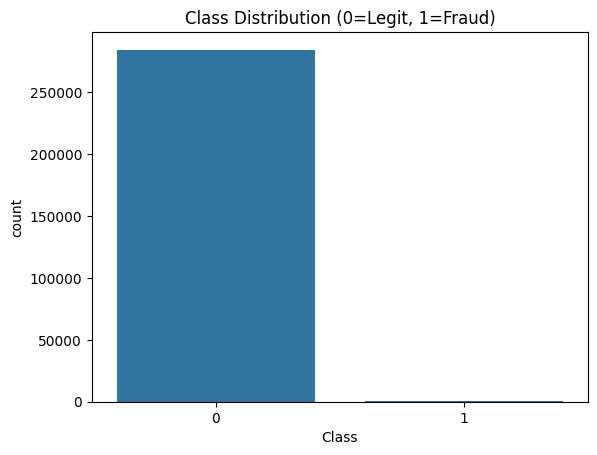

In [3]:
class_counts = df['Class'].value_counts()
class_ratio = df['Class'].value_counts(normalize=True) * 100
print("\nClass Counts:\n", class_counts)
print("\nClass Distribution (%):\n", class_ratio)
# Optional plot
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0=Legit, 1=Fraud)")
plt.show()

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
scaler = StandardScaler()
X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']] = scaler.transform(X_test[['Time','Amount']])

In [7]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 577.2868020304569


In [8]:
lr_model = LogisticRegression(
    class_weight={0:1, 1:scale_pos_weight},
    max_iter=1000,
    solver='liblinear'
)
lr_model.fit(X_train, y_train)
print("\nLogistic Regression trained.")


Logistic Regression trained.


In [9]:
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',

    # Core training params
    learning_rate=0.1,
    n_estimators=300,
    max_depth=6,

    # Speed + memory optimizations
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,

    # Stability
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")
print("Model expects features:", xgb_model.n_features_in_)

XGBoost trained.
Model expects features: 30


In [10]:
threshold = 0.2 # tuned to prioritize recall
# Logistic Regression
y_probs_lr = lr_model.predict_proba(X_test)[:,1]
y_pred_lr = (y_probs_lr >= threshold).astype(int)
# XGBoost
y_probs_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

In [11]:
def evaluate_model(y_true, y_pred, y_probs, model_name="Model"):
    print(f"\n====== {model_name} ======")
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n", cm)
   
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_probs)
   
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Recall (Fraud) : {recall:.4f}")
    print(f"Precision (Fraud) : {precision:.4f}")
    print(f"F1-Score (Fraud) : {f1:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
   
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_probs)
    plt.plot(recall_vals, precision_vals, label=model_name)
   
    return cm


====== Logistic Regression ======

Confusion Matrix:
 [[51333  5531]
 [    6    92]]
Accuracy : 0.9028
Recall (Fraud) : 0.9388
Precision (Fraud) : 0.0164
F1-Score (Fraud) : 0.0322
PR-AUC : 0.7190

====== XGBoost ======

Confusion Matrix:
 [[56851    13]
 [   14    84]]
Accuracy : 0.9995
Recall (Fraud) : 0.8571
Precision (Fraud) : 0.8660
F1-Score (Fraud) : 0.8615
PR-AUC : 0.8816


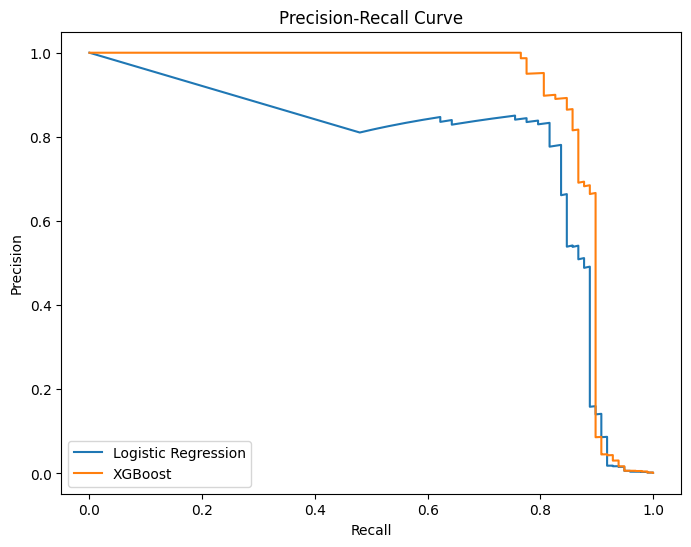

In [12]:
plt.figure(figsize=(8,6))
cm_lr = evaluate_model(y_test, y_pred_lr, y_probs_lr, "Logistic Regression")
cm_xgb = evaluate_model(y_test, y_pred_xgb, y_probs_xgb, "XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [13]:
COST_FN = 500 # Missed fraud
COST_FP = 10 # Blocked legit
def compute_cost(cm, model_name="Model"):
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn*COST_FN + fp*COST_FP
    print(f"{model_name} Total Business Cost: ${total_cost}")
    return total_cost
compute_cost(cm_lr, "Logistic Regression")
compute_cost(cm_xgb, "XGBoost")

Logistic Regression Total Business Cost: $58310
XGBoost Total Business Cost: $7130


np.int64(7130)

In [14]:
import os
import joblib

# Create folder if not exists
os.makedirs("model", exist_ok=True)

# Save model 
joblib.dump(xgb_model, "model/xgb_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")


print("Model saved successfully!")



Model saved successfully!
